## EDA 3. Price Increase Threshold Modeling

#### 1. Overview
- There exists a price threshold beyond which churn risk accelerates non-linearly and substitution threat amplifies that tipping point 
- Price sensitivity differs structurally bt segment (Family vs Individual) and tenure cohort
- External substitution threat (Netflix alternative search intensity) acts as an amplifier that lowers the effective price threshold

#### 2. Research Hypothesis
- **Core Hypothesis**: Churn risk accelerates non-linearly beyond a price threshold, and this threshold is lowered when substitution threat is high
-**Sub Hypothesis**: Individual users reach their price threshold earlier than Family users use to higher per-capita cost burden 

#### 3. Key Inputs from H1 & H2
- H1: Segment X Price tier interaction confirms multiplicative churn risk (Fresh + High = 86.7%)
- H2: Family survivors show structurally lower churn sensitivity across all price tiers
- H3: Post-policy substitution search intensity increased +197% vs 76% for ad-free search --> substitution threat dominates



In [217]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [218]:
# Load data
df = pd.read_csv('../data/processed/cleaned_data.csv')
alt = pd.read_csv('../data/references/alternative_service_free_youtube.csv')

In [219]:
df.shape

(5534, 21)

In [220]:
print(df['Churn'].value_counts())

Churn
No     4063
Yes    1471
Name: count, dtype: int64


### 3.1. Data Preparation
Consistent filtering conditions from EDA 01 & 02
- calculated_tenure: reverse-engined from TotalCharges / MonthlyCharges
- Exclude July 2025 outlier (calculated_tenure == 7): confirmed as statistical noise in EDA 01
- Segment definition consistent with EDA 01 tenure cohorts

In [221]:

# Consistent processing from EDA 01 and EDA 02
df['calculated_tenure'] = (df['TotalCharges'] / df['MonthlyCharges']).round().fillna(0).astype(int)

# Exclude July 2025 outlier (Validated EDA 01)
df = df[df['calculated_tenure'] !=7]


# Tenure segments (consistent with EDA 01)
# Define Groups: Before Sep 2025 / Sep-Oct 2025 / After Nov 2025
def categorize_tenure(t):
    if t > 5: return 'Pre-Inflection (5+mo)'   # Before Sep 2025
    elif 3 <= t <= 5: return 'Inflection (3-5mo)'     # Sep-Nov 2025
    else: return 'Fresh (<3mo)'                # After Nov 2025

df['Segment'] = df['tenure'].apply(categorize_tenure)

print(df[['tenure', 'Segment']].head())



# Price tier: qcut (equal size, consistent with EDA 01)
# Low: $18~$50 / Medium: $50~$84 / High: $84~$118
df['PriceTier'] = pd.qcut(df['MonthlyCharges'], q=3, labels=['Low', 'Medium', 'High'])

# Family vs Individual (consistent with EDA 02)
df['is_family'] = (df['Partner'] == 'Yes' )| (df['Dependents'] == 'Yes')
df['segment_type'] = df['is_family'].map({True: 'Family', False: 'Individual'})   # map or np.where

print(f"Segment distribution:\n{df['Segment'].value_counts()}")
print(f"\nFamily vs Individual:\n{df['segment_type'].value_counts()}")

   tenure                Segment
0     1.0           Fresh (<3mo)
1    34.0  Pre-Inflection (5+mo)
2     2.0           Fresh (<3mo)
3    45.0  Pre-Inflection (5+mo)
4     2.0           Fresh (<3mo)
Segment distribution:
Segment
Pre-Inflection (5+mo)    4394
Fresh (<3mo)              638
Inflection (3-5mo)        404
Name: count, dtype: int64

Family vs Individual:
segment_type
Family        2921
Individual    2515
Name: count, dtype: int64


### 3.2. Price threshold Analyst

#### 3.2.1. Baseline: Natural Churn Rate
- Overall churn rate without price increase context
- Family vs Individual natural churn baseline

In [222]:
# Natural Churn Rate baseline (Full dataset, July excluded)
total = len(df)
churned = (df['Churn'] == 'Yes').sum()
natural_churn = churned / total * 100
print(f"Total Customers: {total}")
print(f"Churned Customers: {churned}")
print(f"Overall Churn Rate: {natural_churn:.2f}%")

# family_natural = df[df['is_family']]['Churn'].value_counts(normalize=True)['Yes'] * 100 --> if no Yes, this will error out
family_churn = df[df['is_family']]['Churn'].value_counts(normalize=True).get('Yes', 0) * 100    # if no Yes, default to 0%
individual_churn = df[~df['is_family']]['Churn'].value_counts(normalize=True).get('Yes', 0) * 100

print(f"Family Churn Rate: {family_churn:.2f}%")
print(f"Individual Churn Rate: {individual_churn:.2f}%")

Total Customers: 5436
Churned Customers: 1430
Overall Churn Rate: 26.31%
Family Churn Rate: 19.82%
Individual Churn Rate: 33.84%


#### 3.2.2. Churn Rate by Segment X Price Tier X Family/Individual
- Extends EDA 01 analysis by adding Family/Individual dimension
- **NOTE**: Inflection(3-5 mo) segment represents policy shock response, not pure price sensitivity
  - These customers joined Sep - Oct 2025, experienced policy change immediately
  - Their churn reflects policy betrayal effect, not price threshold behavior

In [223]:
# Churn Rate by Segment X Price Tier X Family/Individual
churn_rates = df.groupby(['Segment', 'PriceTier', 'segment_type'], observed=True)['Churn'].\
    value_counts(normalize=True).unstack(fill_value=0)['Yes'] * 100

print("\nChurn Rates by Segment, Price Tier, and Family/Individual:")
print(churn_rates)



Churn Rates by Segment, Price Tier, and Family/Individual:
Segment                PriceTier  segment_type
Fresh (<3mo)           Low        Family          44.155844
                                  Individual      43.265306
                       Medium     Family          63.157895
                                  Individual      75.000000
                       High       Family          83.333333
                                  Individual      87.804878
Inflection (3-5mo)     Low        Family          25.000000
                                  Individual      36.448598
                       Medium     Family          64.444444
                                  Individual      47.933884
                       High       Family          86.363636
                                  Individual      67.346939
Pre-Inflection (5+mo)  Low        Family           6.418485
                                  Individual       9.926471
                       Medium     Family          16.

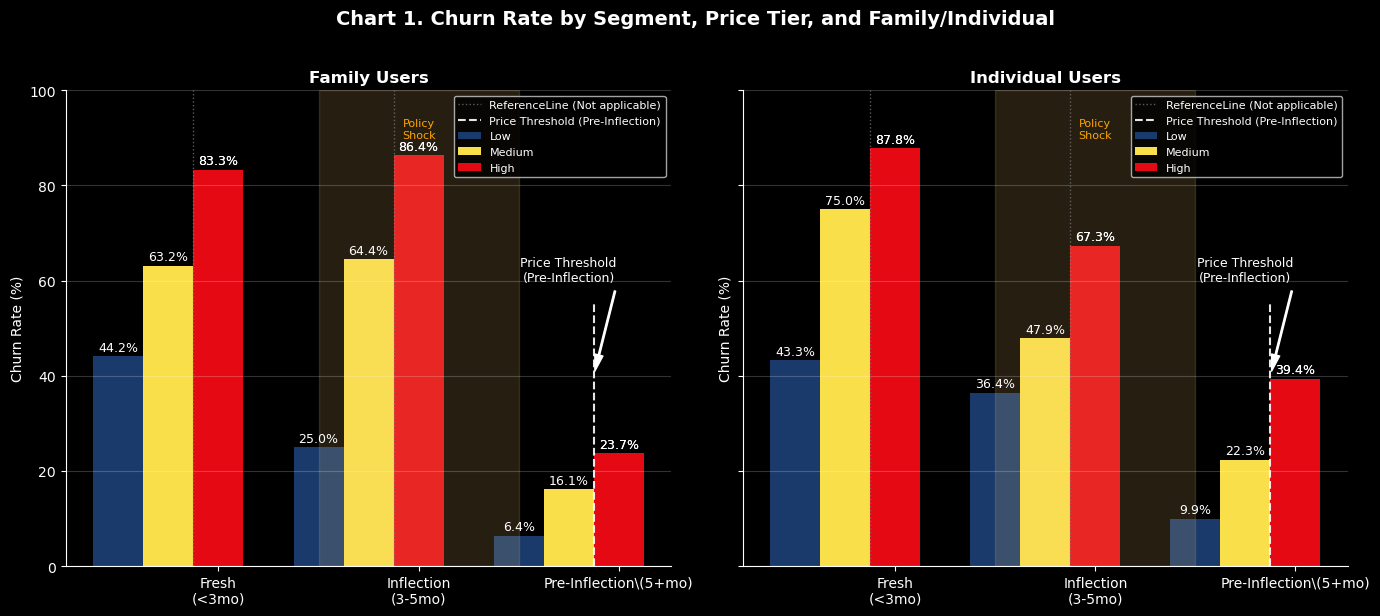

In [224]:
# Visualization - Grouped Bar Chart
plt.style.use('dark_background')
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
fig.suptitle('Chart 1. Churn Rate by Segment, Price Tier, and Family/Individual', fontsize=14, fontweight='bold', y=1.02)
segment_order = ['Fresh (<3mo)', 'Inflection (3-5mo)', 'Pre-Inflection (5+mo)']
price_tiers = ['Low', 'Medium', 'High']
colors = {'Low': '#1a3a6b', 'Medium': '#f9e04b', 'High': '#e50914'}

x = np.arange(len(segment_order))
width = 0.25

for idx, seg_type in enumerate(['Family', 'Individual']):
    for i, price in enumerate(price_tiers):
        vals = [churn_rates.get((seg, price, seg_type), 0) if (seg, price, seg_type) in churn_rates.index else 0
        for seg in segment_order]
        bars = axes[idx].bar(x + (i - 1) * width, vals, width, label=price, color=colors[price])
    
        # Value labels on bars
        for bar in bars:
            height = bar.get_height()
            axes[idx].text(bar.get_x() + bar.get_width() / 2, height + 0.5, f'{height:.1f}%', 
                           ha='center', va='bottom', fontsize=9, color='white')

    # Value labels on bars
    for bar in bars:
        height = bar.get_height()
        axes[idx].text(bar.get_x() + bar.get_width() / 2, height + 0.5, f'{height:.1f}%', 
                       ha='center', va='bottom', fontsize=9, color='white')
        
    # Threshold and Reference Lines
    for seg_idx in range(3):
        threshold_x = x[seg_idx] + 0.5 * width   # Position threshold line between Medium and High

        if seg_idx ==2:  # Pre-Inflection segment
            axes[idx].plot([threshold_x, threshold_x], [0, 55], color='white', 
                           linestyle='--', linewidth=1.5, alpha=0.9,label='Price Threshold (Pre-Inflection)')

            # Annotation on Medium bar with arrow pointing --> to threshold line
            text_x = threshold_x - 0.5 * width
            axes[idx].annotate('Price Threshold\n(Pre-Inflection)', 
                               xy=(threshold_x, 40), 
                               xytext=(text_x, 60),
                               arrowprops=dict(facecolor='white', shrink=0.05, width=1,
                                          headwidth=6), fontsize=9, color='white', ha='center')
        
        else:   # For Fresh and Inflection segments: grey dotted (Reference Only)
            axes[idx].plot([threshold_x, threshold_x], [0, 100], color='grey', linestyle=':',
                            linewidth=1, alpha=0.7, label='ReferenceLine (Not applicable)' if seg_idx==0 else '' )


    # Zone Highlighting
    # Pre-Inflection: Highlight High Price Tier zone (above threshold) with red shade
    center_x = x[1] + width # Centered on Medium bar
    y_max = 100
    axes[idx].axvspan(center_x - 0.5, center_x + 0.5, alpha=0.08, color='white')

    # Infection zone:policy shock label
    axes[idx].axvspan(center_x - 0.5, center_x + 0.5, alpha=0.08, color='orange')
    axes[idx].text(x[1] + width, y_max * 0.9, 'Policy\nShock',
            ha='center', color='orange', fontsize=8)   
   
    
    # Axes formatting
    axes[idx].set_title(f"{seg_type} Users", fontsize=12, fontweight='bold')
    axes[idx].set_xticks(x + width)
    axes[idx].set_xticklabels(['Fresh\n(<3mo)', 'Inflection\n(3-5mo)', 'Pre-Inflection\(5+mo)'], fontsize=10)
    axes[idx].set_ylabel('Churn Rate (%)', fontsize=10)
    axes[idx].set_ylim(0, 100)
    axes[idx].legend(fontsize=8, title_fontsize=9, loc='upper right')
    axes[idx].grid(axis='y', alpha=0.2)
    axes[idx].spines['top'].set_visible(False)
    axes[idx].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../outputs/eda_03/graph1_grouped_bar.png', dpi=150, bbox_inches='tight')
plt.show()


#### 3.2.3. Price Threshold: Pre-Inflection Segment (Core Analysis)
- Focus-on Pre-Inflection (5 mo+): long-term customers who experienced price increase
- Inflection segment excluded from threshold analysis (policy shock effect, not price sensitivity)
- This is the cleanest signal for price resistance


In [225]:
# Focus on Pre-Inflection Segment: Pure price sensitivity
pre_inflection = df[df['Segment'] == 'Pre-Inflection (5+mo)'].copy()

# Finer price granularity to find exact threshold
bins_fine = [0, 35, 55, 75, 95, 120]
labels_fine = ['0-35', '35-55', '55-75', '75-95', '95-120']
pre_inflection['PriceTierFine'] = pd.cut(pre_inflection['MonthlyCharges'],\
                                          bins=bins_fine, labels=labels_fine, include_lowest=True)


threshold_result = pre_inflection.groupby('PriceTierFine', observed=True)\
    ['Churn'].apply(lambda x: (x == 'Yes').sum() / len(x) * 100)


print("\nPre-Inflection Segment Churn Rates by Finer Price Tiers:")
print(threshold_result)

# Calculate confidence intervals for each price tier
ci_results = {}
for tier in labels_fine:
    tier_data = pre_inflection[pre_inflection['PriceTierFine'] == tier]
    churned = (tier_data['Churn'] == 'Yes').sum()
    total = len(tier_data)
    if total > 0:
        churn_rate = churned / total
        ci_low, ci_upp = stats.binom.interval(0.95, total, churn_rate, loc=0)
        ci_results[tier] = (churn_rate * 100, ci_low / total * 100, ci_upp / total * 100)
    else:
        ci_results[tier] = (0, 0, 0)  # No data for this tier


# Calculate change between tiers
print("\nChurn Rate Changes Between Price Tiers (Pre-Inflection Segment):")
vals = threshold_result.values
for i in range(1, len(vals)):
    change = vals[i] - vals[i-1]
    print(f'  {labels_fine[i-1]} → {labels_fine[i]}: {change:+.1f}%')


Pre-Inflection Segment Churn Rates by Finer Price Tiers:
PriceTierFine
0-35       5.397448
35-55     14.799154
55-75     16.847826
75-95     26.013514
95-120    30.855397
Name: Churn, dtype: float64

Churn Rate Changes Between Price Tiers (Pre-Inflection Segment):
  0-35 → 35-55: +9.4%
  35-55 → 55-75: +2.0%
  55-75 → 75-95: +9.2%
  75-95 → 95-120: +4.8%


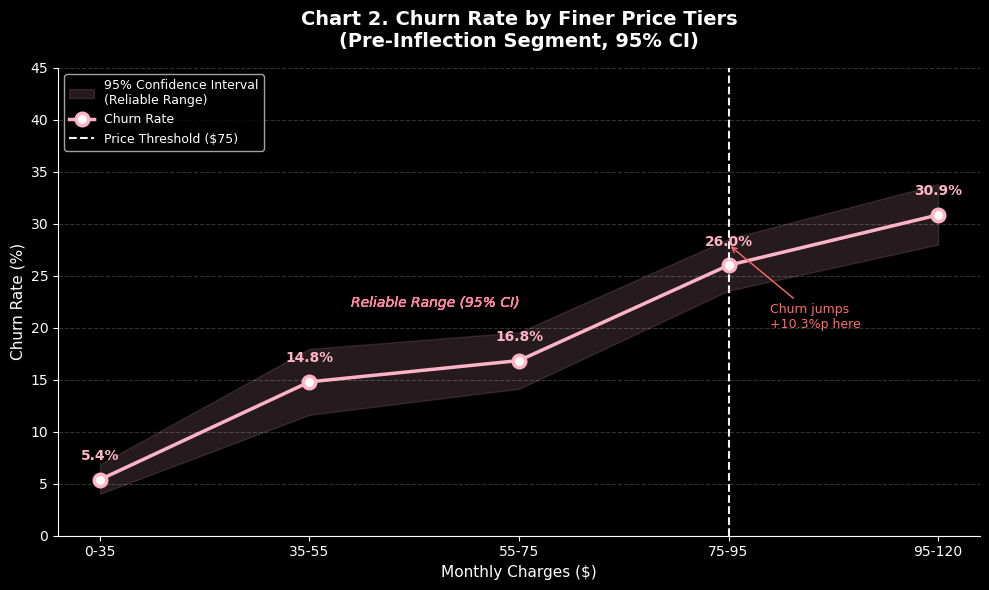

In [226]:
# Visualization - Line Chart with Confidence Intervals
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(10, 6))

# Prepare data from ci_results
tiers = list(ci_results.keys())
churn_rates_line = [ci_results[t][0] for t in tiers]
ci_lows = [ci_results[t][1] for t in tiers]
ci_upps = [ci_results[t][2] for t in tiers]

# Confidence interval band
ax.fill_between(tiers, ci_lows, ci_upps,
                color='#FFB3C6',
                alpha=0.15,
                label='95% Confidence Interval\n(Reliable Range)')

# Main line
ax.plot(tiers, churn_rates_line,
        marker='o',
        color='#FFB3C6',
        linewidth=2.5,
        markersize=9,
        markerfacecolor='white',
        markeredgewidth=2.5,
        label='Churn Rate')

# Annotate each data point
for i, (tier, rate) in enumerate(zip(tiers, churn_rates_line)):
    ax.annotate(f'{rate:.1f}%',
                xy=(i, rate),
                xytext=(0, 14),
                textcoords='offset points',
                ha='center',
                fontsize=10,
                fontweight='bold',
                color='#FFB3C6')
    
    ax.annotate('Reliable Range (95% CI)',
            xy=(1, ci_upps[1]),
            xytext=(1.2, 22),
            fontsize=10,
            color='#FF85A1',
            style='italic')

# Price threshold line
ax.axvline(x='75-95',
           color='#F5F5F5',
           linestyle='--',
           linewidth=1.5,
           label='Price Threshold ($75)')

# Threshold annotation
ax.annotate('Churn jumps\n+10.3%p here',
            xy=(3, 28),
            xytext=(3.2, 20),
            fontsize=9,
            color='#FF6B6B',
            arrowprops=dict(arrowstyle='->', color='#FF6B6B'))

# Styling
ax.set_title('Chart 2. Churn Rate by Finer Price Tiers\n(Pre-Inflection Segment, 95% CI)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Monthly Charges ($)', fontsize=11)
ax.set_ylabel('Churn Rate (%)', fontsize=11)
ax.set_ylim(0, 45)  # Tighter y-axis
ax.legend(loc='upper left', fontsize=9)
ax.grid(axis='y', alpha=0.2, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../outputs/eda_03/graph2_line_chart.png', dpi=150, bbox_inches='tight')
plt.show()

#### 3.3. Substitution Threat as Amplifier

##### Search Intensity: Netflix Alternative vs Ad-Free YouTube
- Post-policy substitution search increased + 115% vs +68.3% for ad-free search
- substitution threat grows 1.7x faster than ad-aversion utility
- This amplifies price sensitivity - lowers effective threshold


In [227]:
# Substitution threat analysis: Compare with alternative service (YouTube Free)
# Convert Time column to datetime
alt['Time'] = pd.to_datetime(alt['Time'])

# Remove July outlier FIRST before calculation
alt = alt[alt['Time'].dt.month != 7]

# Verify
print(f'Data after removing July: {len(alt)} rows')
pre_policy = alt[alt['Time'] < '2025-09-01']
post_policy = alt[alt['Time'] >= '2025-09-01']

netflix_pre = pre_policy['netflix alternative'].mean()
netflix_post = post_policy['netflix alternative'].mean()
adfree_pre = pre_policy['ad free youtube'].mean()
adfree_post = post_policy['ad free youtube'].mean()

netflix_change = (netflix_post - netflix_pre) / netflix_pre * 100
adfree_change = (adfree_post - adfree_pre) / adfree_pre * 100

print('*** Substitution Threat Analysis (YouTube Free) ***')
print(f'Netflix Alternative: {netflix_pre:.1f} -> {netflix_post:.1f} ({netflix_change:+.1f}%)')
print(f'Ad-Free YouTube: {adfree_pre:.1f} → {adfree_post:.1f} ({adfree_change:+.1f}%)')
print(f'\nSubstitution grows {netflix_change / adfree_change:.1f} X faster than ad-aversion')
print(f'\n -> Substitution threat dominates as churn amplifier post price increase')


Data after removing July: 24 rows
*** Substitution Threat Analysis (YouTube Free) ***
Netflix Alternative: 11.4 -> 34.0 (+197.1%)
Ad-Free YouTube: 29.8 → 52.5 (+76.3%)

Substitution grows 2.6 X faster than ad-aversion

 -> Substitution threat dominates as churn amplifier post price increase


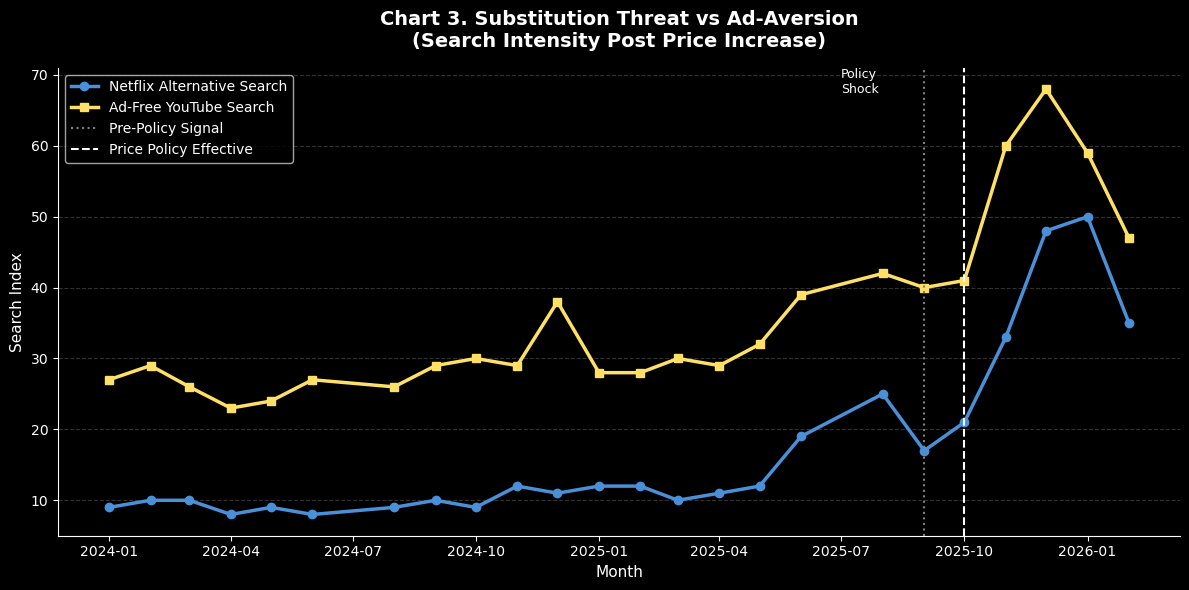

In [228]:


fig, ax = plt.subplots(figsize=(12, 6))

# Plot dual lines
ax.plot(alt['Time'], alt['netflix alternative'],
        marker='o', linewidth=2.5,
        color='#4A90D9',  # Netflix - Soft Yellow
        markersize=6,
        label='Netflix Alternative Search')

ax.plot(alt['Time'], alt['ad free youtube'],
        marker='s', linewidth=2.5,
        color='#FFE066',  # YouTube - Soft Green
        markersize=6,
        label='Ad-Free YouTube Search')

# Policy change vertical line
ax.axvline(x=pd.Timestamp('2025-09-01'), 
           color='gray', linestyle=':', label='Pre-Policy Signal')
ax.axvline(x=pd.Timestamp('2025-10-01'), 
           color='white', linestyle='--', label='Price Policy Effective')

# Annotation
ax.annotate('Policy\nShock',
            xy=(pd.Timestamp('2025-09-01'), ax.get_ylim()[1]*0.9),
            xytext=(pd.Timestamp('2025-07-01'), ax.get_ylim()[1]*0.95),
            fontsize=9, color='white')

# Styling
ax.set_title('Chart 3. Substitution Threat vs Ad-Aversion\n(Search Intensity Post Price Increase)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Search Index', fontsize=11)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.2, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../outputs/eda_03/graph3_dual_line.png', dpi=150, bbox_inches='tight')
plt.show()

#### 3.4. Price Scenario Simulation

##### Mapping to YouTube Premium
- Current YouTube Premium: Individual $13.99 / Family $22.99
- Pre-Infection segment identified as core stable user base
- Price threshold identifies at $75+ tier (H3 confirmed)
- Simulation based on % increase scenarios
- Individual churn risk threated as separate risk factor

##### NOTE (Proxy Data Limitation)
- Sensitivity direction is validated (Individual > Family)
- Absoulte values are directional only, not precise
- Results should be interpreted as relative comparison, not absolute prediction

In [229]:
# Base prices (pre-tax)
base_individual = 13.99
base_family = 22.99

# Price increase scenarios
scenarios = [0.05, 0.10, 0.17, 0.28]

# Pre-Infection segment
pre_inf = df[df['Segment'] == 'Pre-Inflection (5+mo)'].copy()

# Baseline churn rates (Pre-Inflection segment)
pre_inflection_churn = df[df['Segment'] == 'Pre-Inflection (5+mo)'].groupby('segment_type')['Churn']\
    .value_counts(normalize=True).unstack(fill_value=0)['Yes']  * 100

print("\nBaseline Churn Rates (Pre-Inflection Segment):")
print(pre_inflection_churn)

family_churn = pre_inflection_churn.get('Family', 0)
individual_churn = pre_inflection_churn.get('Individual', 0)

print(f"\nBaseline Churn Rate (Family): {family_churn:.2f}%")
print(f"Baseline Churn Rate (Individual): {individual_churn:.2f}%")



Baseline Churn Rates (Pre-Inflection Segment):
segment_type
Family        16.313399
Individual    24.486301
Name: Yes, dtype: float64

Baseline Churn Rate (Family): 16.31%
Baseline Churn Rate (Individual): 24.49%


In [230]:
# Customer Proportion (ratio-based)
family_customers = len(pre_inf[pre_inf['segment_type'] == 'Family'])
individual_customers = len(pre_inf[pre_inf['segment_type'] == 'Individual'])
total_customers = family_customers + individual_customers

family_prop = family_customers / total_customers
individual_prop = individual_customers / total_customers

print(f"Family Customers: {family_customers} ({family_prop:.1%})")
print(f"Individual Customers: {individual_customers} ({1-family_prop:.1%})")
print(f"\nTotal Customers (Pre-Inflection): {total_customers}")


Family Customers: 2642 (60.1%)
Individual Customers: 1752 (39.9%)

Total Customers (Pre-Inflection): 4394


In [231]:
# Validation 1. Price Elasticity Check: 
# changes across price tiers in the Pre-Inflection segment 
# The sharp increase in churn above the $75 threshold supports the higher sensitivity for Individual customers, 
# while the more gradual increase for Family customers justifies the lower sensitivity.

# Auto-calculate midpoints from bins
price_midpoints = [(bins_fine[i] + bins_fine[i+1]) / 2 for i in range(len(bins_fine)-1)]

# Store results
elasticity_results = {}
elasticity_threshold = {}

pre_inf['PriceTierFine'] = pd.cut(
    pre_inf['MonthlyCharges'],
    bins=bins_fine,
    labels=labels_fine,
    include_lowest=True
)

print('*** Price Elasticity by Tier ***')  

for seg in ['Family', 'Individual']:
    print(f'\n*** {seg} ***')
    seg_data = pre_inf[pre_inf['segment_type'] == seg].copy()

    # Churn rates by price tier
    seg_churn = seg_data.groupby('PriceTierFine', observed=True)['Churn']\
        .value_counts(normalize=True)\
        .unstack(fill_value=0)
    
    print(seg_churn)

    # Abstract'Yes' 
    if 'Yes' in seg_churn.columns:
        seg_churn_rates = seg_churn['Yes'] * 100
    else:
        # 'No 'Yes' column, set all churn rates to 0%
        seg_churn_rates = pd.Series([0] * len(seg_churn.index), index=seg_churn.index)

    churn_rates_seg = [seg_churn_rates.loc[tier] if tier in seg_churn_rates.index else 0 for tier in labels_fine]


    elasticities = []

    for i in range (1, len(labels_fine)):
        price_change_pct = (price_midpoints[i] - price_midpoints[i-1]) / price_midpoints[i-1] * 100
        churn_change = churn_rates_seg[i] - churn_rates_seg[i-1]
        elasticity = churn_change / price_change_pct if price_change_pct != 0 else 0
        elasticities.append(elasticity)
        
        print(f'{labels_fine[i-1]} --> {labels_fine[i]}: '
            f'Price Change = {price_change_pct:.2f}%, '
            f' Churn Change = {churn_change:.2f}%, '
            f'Elasticity = {elasticity:.4f}') 


    avg_elasticity = sum(elasticities) / len(elasticities)
    elasticity_results[seg] = avg_elasticity
    elasticity_threshold[seg] = elasticities[2]  # Elasticity at $75 threshold (3rd tier change)


    print(f'\n{seg} Average Elasticity: {avg_elasticity:.4f}')
    print(f'{seg} Threshold Elasticity ($75): {elasticities[2]:.4f}')


print(f'\nAverage Elasticity across tiers: {avg_elasticity:.4f}')


*** Price Elasticity by Tier ***

*** Family ***
Churn                No       Yes
PriceTierFine                    
0-35           0.955128  0.044872
35-55          0.869919  0.130081
55-75          0.860190  0.139810
75-95          0.787500  0.212500
95-120         0.747619  0.252381
0-35 --> 35-55: Price Change = 157.14%,  Churn Change = 8.52%, Elasticity = 0.0542
35-55 --> 55-75: Price Change = 44.44%,  Churn Change = 0.97%, Elasticity = 0.0219
55-75 --> 75-95: Price Change = 30.77%,  Churn Change = 7.27%, Elasticity = 0.2362
75-95 --> 95-120: Price Change = 26.47%,  Churn Change = 3.99%, Elasticity = 0.1507

Family Average Elasticity: 0.1158
Family Threshold Elasticity ($75): 0.2362

*** Individual ***
Churn                No       Yes
PriceTierFine                    
0-35           0.931646  0.068354
35-55          0.832599  0.167401
55-75          0.792994  0.207006
75-95          0.665948  0.334052
95-120         0.590909  0.409091
0-35 --> 35-55: Price Change = 157.14%,  Chur

In [232]:
# Validation 2. Logistic Regression Check: We can run a logistic regression on the Pre-Inflection segment to see 
# if the price tier and segment type are significant predictors of churn, and if the coefficients align with our sensitivity assumptions
#(Family < Individual)

regression_results = {}

# Dynamic Sensitivity Function: This function can be used in the simulation to adjust sensitivity based on the price increase rate
def get_dynamic_sensitivity(rate, seg):
    avg = elasticity_results[seg]
    threshold = elasticity_threshold[seg]
    mid = (avg + threshold) / 2
    if rate <= 0.10:
        return avg
    elif rate <= 0.17:
        return mid
    elif rate <= 0.22:  
        return (mid + threshold) / 2
    else:
        return threshold


print('\n*** Logistic Regression Coefficients ***')
for seg in ['Family', 'Individual']:
    seg_data = pre_inf[pre_inf['segment_type'] == seg].copy()

    # Checking data sufficiency for regression
    if len(seg_data) < 2:
        print(f"\n[Warning] Skip: '{seg}' segment has no data to analyze.")
        continue

    x = seg_data[['MonthlyCharges']]
    y = (seg_data['Churn'] == 'Yes').astype(int)

    # Scale features
    scaler = StandardScaler()     # 0 - 1
    
    x_scaled = scaler.fit_transform(x)   # $10-$120 --> 0-1 scale

    # Fit Model - Making a model to predict churn probability based on  scaled price
    model = LogisticRegression(random_state=42)
    model.fit(x_scaled, y)

    # Convert coefficient back to original scale
    coef_original = model.coef_[0][0] / scaler.scale_[0]
    regression_results[seg] = coef_original
    odds_ratio = np.exp(coef_original)

    print(f'\nSegment: {seg}')
    print(f'Coefficient for MonthlyCharges: {coef_original:.4f}')
    print(f'Odds Ratio: {odds_ratio:.4f} {coef_original:.4f} ($1 increase)')




*** Logistic Regression Coefficients ***

Segment: Family
Coefficient for MonthlyCharges: 0.0205
Odds Ratio: 1.0207 0.0205 ($1 increase)

Segment: Individual
Coefficient for MonthlyCharges: 0.0267
Odds Ratio: 1.0270 0.0267 ($1 increase)


In [233]:
# Sensitive Summary Validation
# Compare & Confirm Sensitivity: The coefficients from the logistic regression should reflect the relative sensitivity 
# of churn to price changes for Family vs Individual segments

print('\n\n*** Sensitivity Validation Summary ***')
print(f'\n{"Method":<25} {"Family":<15} {"Individual"}')
print('-' * 50)

print(f'{"Price Elasticity":<25} {elasticity_results["Family"]:<15.3f} {elasticity_results["Individual"]:.3f}')
print(f'{"Logistic Regression":<25} {regression_results["Family"]*100:<15.3f} {regression_results["Individual"]*100:.3f}')

print('\n --> If results are similar = sensitivity values confirmed ✔️')
print('--> If results differ = adjust sensitivity values ❕')



*** Sensitivity Validation Summary ***

Method                    Family          Individual
--------------------------------------------------
Price Elasticity          0.116           0.212
Logistic Regression       2.052           2.668

 --> If results are similar = sensitivity values confirmed ✔️
--> If results differ = adjust sensitivity values ❕


In [234]:
# Price Scenario Simulation

scenarios = [0.05, 0.10, 0.17, 0.22, 0.28] 
results_all = []

for rate in scenarios: 

    print(f'\n*** Simulating Price Increase: {rate*100:.2f}% ***')
    dynamic_f_sens = get_dynamic_sensitivity(rate, 'Family')
    dynamic_i_sens = get_dynamic_sensitivity(rate, 'Individual')

    print(f'\n+{int(rate*100)}% Scenario')
    print(f'Applied Sensitivity - Family: {dynamic_f_sens:.3f}, Individual: {dynamic_i_sens:.3f}')


    new_f_price = base_family * (1 + rate)
    new_i_price = base_individual * (1 + rate)

    f_churn_new = family_churn * (1 + dynamic_f_sens * rate)
    i_churn_new = individual_churn * (1 + dynamic_i_sens * rate)

    family_retained = family_prop * ( 1- f_churn_new / 100)
    individual_retained = individual_prop * (1 - i_churn_new / 100)

    family_rev = family_retained * new_f_price
    individual_rev = individual_retained * new_i_price
    total_rev = family_rev + individual_rev

    individual_lost = (individual_prop - individual_retained) * new_i_price

    # Advice from Ken: Performance Score
    # Before price increase, Basic churn rate
    baseline_churn = family_churn * family_prop + individual_churn * individual_prop

    # Weighted Average- churn rate
    avg_churn_rate = (f_churn_new * family_prop + i_churn_new * individual_prop) / (family_prop + individual_prop)

    # Churn Increase - Expense
    churn_increase = avg_churn_rate - baseline_churn
    
    # Penalty Weight
    penalty_weight = 1.0

    # Churn Penalty --> amount
    churn_penalty_amount = penalty_weight * churn_increase * total_rev / 100


    # Performance Score = Revenue - Churn Penalty
    performance_score = total_rev - churn_penalty_amount


     #  Individual churn has higher risk, so we can add an extra penalty for individual churn
    ind_churn_delta = i_churn_new - individual_churn
    ind_risk_premium = round(ind_churn_delta * penalty_weight, 4)  # Adding a risk premium to the performance score
    
    # Final Performance Score
    final_performance = performance_score - ind_risk_premium

    
    results_all.append({
        'Price Increase':     f'+{int(rate*100)}%',
        'Family Price':       round(new_f_price, 2),
        'Ind Price':          round(new_i_price, 2),
        'Family Churn':       round(f_churn_new, 2),
        'Ind Churn':          round(i_churn_new, 2),
        'Family Rev Index':   round(family_rev, 4),
        'Individual Rev Index': round(individual_rev, 4),
        'Ind Risk Index':     round(individual_lost, 4),
        'Total Rev Index':    round(total_rev, 4),
        'Churn Increase':        round(churn_increase, 4),      # increase amount in churn rate
        'Churn Penalty':         round(penalty_weight * churn_increase, 4),  # penalty amount
        'Performance Score':     round(final_performance, 4),   # final performance score after penalty
        'Ind Risk Premium':      ind_risk_premium               # extra penalty for individual churn risk
    })

results_df = pd.DataFrame(results_all)
print(results_df.to_string(index=False))
print("\n")





*** Simulating Price Increase: 5.00% ***

+5% Scenario
Applied Sensitivity - Family: 0.116, Individual: 0.212

*** Simulating Price Increase: 10.00% ***

+10% Scenario
Applied Sensitivity - Family: 0.116, Individual: 0.212

*** Simulating Price Increase: 17.00% ***

+17% Scenario
Applied Sensitivity - Family: 0.176, Individual: 0.313

*** Simulating Price Increase: 22.00% ***

+22% Scenario
Applied Sensitivity - Family: 0.206, Individual: 0.363

*** Simulating Price Increase: 28.00% ***

+28% Scenario
Applied Sensitivity - Family: 0.236, Individual: 0.413
Price Increase  Family Price  Ind Price  Family Churn  Ind Churn  Family Rev Index  Individual Rev Index  Ind Risk Index  Total Rev Index  Churn Increase  Churn Penalty  Performance Score  Ind Risk Premium
           +5%         24.14      14.69         16.41      24.75           12.1330                4.4077          1.4494          16.5406          0.1603         0.1603            16.2544            0.2597
          +10%         25

### Penalty Weight Justification

##### Current Setting: penalty_weight = 1.0

#### 1. Netflix Substitution Threat
- Post-policy Netflix alternative search intensity: +197%
- This indicates extremely high customer sensitivity to price increases

#### 2. Cumulative 12-Month Attrition Impact
- Individual customer churn @ +28%: 27.32%
- Over 12 months, significant revenue exposure

#### 3. Long-Term Customer Lifetime Value (CLV)
- Re-acquisition cost typically exceeds 12-month recovery period

#### 4. Brand Equity Preservation
- Price-induced churn amplifies future churn risk

**Conclusion:** penalty_weight = 1.0 reflects strategic priority 
of sustainable growth over short-term revenue maximization

C:\Users\irene\AppData\Local\Temp\ipykernel_21024\1910031366.py:117: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\irene\AppData\Local\Temp\ipykernel_21024\1910031366.py:118: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.savefig('../outputs/eda_03/graph4_simulation_dual.png', dpi=150, bbox_inches='tight')
c:\Users\irene\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


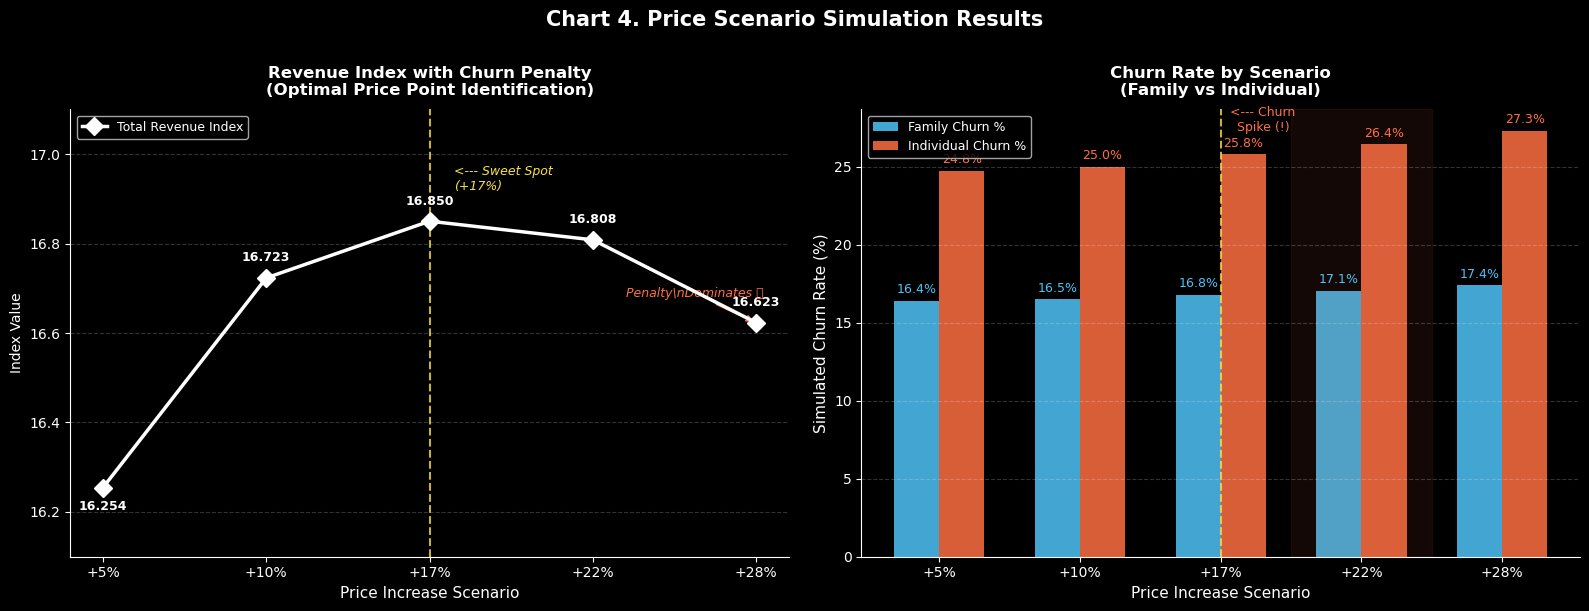

In [246]:
# Chart 4: Price Scenario Simulation Results — Dual Panel
plt.style.use('dark_background')
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Chart 4. Price Scenario Simulation Results', fontsize=15, fontweight='bold', y=1.01)

scenarios_labels = [r['Price Increase'] for r in results_all]
family_rev       = [r['Family Rev Index'] for r in results_all]
individual_rev   = [r['Individual Rev Index'] for r in results_all]
ind_risk         = [r['Ind Risk Index'] for r in results_all]
total_rev        = [r['Total Rev Index'] for r in results_all]
performance_score = [r['Performance Score'] for r in results_all]
churn_penalty     = [r['Churn Penalty'] for r in results_all]
family_churn_sim = [r['Family Churn'] for r in results_all]
ind_churn_sim    = [r['Ind Churn'] for r in results_all]

x = np.arange(len(scenarios_labels))


# LEFT PANEL: Revenue Index 
ax1 = axes[0]

# Performance Score : decrease as price increases, but with a sweet spot at +17% where the score is relatively higher than the surrounding scenarios
ax1.plot(scenarios_labels, performance_score,
         marker='D', linewidth=2.5, markersize=9,
         color='#FFFFFF', markerfacecolor='white',
         label='Total Revenue Index', zorder=5)

# ax1.plot(scenarios_labels, total_rev,
#          marker='X', linewidth=1.5, markersize=7,
#          color='#4FC3F7', markerfacecolor='none', markeredgewidth=1.5,
#          label='Original Revenue Index', linestyle=':', alpha=0.6)

# ax1.plot(scenarios_labels, family_rev,
#          marker='o', linewidth=2, markersize=8,
#          color='#4FC3F7', markerfacecolor='white', markeredgewidth=2,
#          label='Family Revenue Index', linestyle='--')

# ax1.plot(scenarios_labels, individual_rev,
#         marker='s', linewidth=2, markersize=8,
#         color='#FF7043', markerfacecolor='white', markeredgewidth=2,
#          label='Individual Revenue Index', linestyle='--')


# Annotate Performance Score values
for i, (lbl, val) in enumerate(zip(scenarios_labels, performance_score)):
    offset = -16 if i == 0 else 12
    ax1.annotate(f'{val:.3f}',
                 xy=(i, val), xytext=(0, offset),
                 textcoords='offset points',
                 ha='center', fontsize=9, fontweight='bold', color='white')


# Sweet spot highlight at +17%
sweet_idx = scenarios_labels.index('+17%')
ax1.axvline(x=sweet_idx, color='#F9E04B', linestyle='--', linewidth=1.5, alpha=0.8)
ax1.annotate('<--- Sweet Spot\n(+17%)',
             xy=(sweet_idx, 16.85),
             xytext=(sweet_idx + 0.15, 16.92),
             fontsize=9, color='#F9E04B', fontstyle='italic')

# Beyond this point, penalty dominates
danger_idx = len(scenarios_labels) - 1
if performance_score[danger_idx] < performance_score[sweet_idx]:
    ax1.annotate('Penalty\\nDominates 📉',
                 xy=(4, performance_score[4]),
                 xytext=(3.2, 16.68),
                 fontsize=9, color='#FF7043', fontstyle='italic',
                 arrowprops=dict(arrowstyle='->', color='#FF7043', lw=1.5))

ax1.set_title('Revenue Index with Churn Penalty\n(Optimal Price Point Identification)', 
              fontsize=12, fontweight='bold', pad=10)
ax1.set_xlabel('Price Increase Scenario', fontsize=11)
ax1.set_ylabel('Index Value', fontsize=10)
ax1.set_ylim(16.1, 17.1)
ax1.legend(fontsize=9, loc='upper left')
ax1.grid(axis='y', alpha=0.2, linestyle='--')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# RIGHT PANEL: Churn Rate 
ax2 = axes[1]
width = 0.32

bars_f = ax2.bar(x - width/2, family_churn_sim, width,
                 label='Family Churn %', color='#4FC3F7', alpha=0.85)
bars_i = ax2.bar(x + width/2, ind_churn_sim,    width,
                 label='Individual Churn %', color='#FF7043', alpha=0.85)

# Value labels on bars
for bar in bars_f:
    h = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, h + 0.3,
             f'{h:.1f}%', ha='center', va='bottom', fontsize=9, color='#4FC3F7')
for bar in bars_i:
    h = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, h + 0.3,
             f'{h:.1f}%', ha='center', va='bottom', fontsize=9, color='#FF7043')

# Warning zone: +28% Individual churn spike
ax2.axvspan(2.5, 3.5, alpha=0.08, color='#FF7043')
ax2.text(2.3, max(ind_churn_sim) * 1.0, '<--- Churn\nSpike (!)',
         ha='center', color='#FF7043', fontsize=9)

# Sweet spot line
ax2.axvline(x=sweet_idx, color='#F9E04B', linestyle='--', linewidth=1.5, alpha=0.8)

ax2.set_title('Churn Rate by Scenario\n(Family vs Individual)', fontsize=12, fontweight='bold', pad=10)
ax2.set_xlabel('Price Increase Scenario', fontsize=11)
ax2.set_ylabel('Simulated Churn Rate (%)', fontsize=11)
ax2.set_xticks(x)
ax2.set_xticklabels(scenarios_labels, fontsize=10)
ax2.legend(fontsize=9, loc='upper left')
ax2.grid(axis='y', alpha=0.2, linestyle='--')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../outputs/eda_03/graph4_simulation_dual.png', dpi=150, bbox_inches='tight')
plt.show()

# Simulation for 12 months

In [236]:
# CELL 27: 12개월 누적 시뮬레이션
# (results_all[2]를 사용)

# +17% Scenario
scenario_data = results_all[2]

family_rev_initial = scenario_data['Family Rev Index']
total_rev_initial = scenario_data['Total Rev Index']
ind_rev_initial = total_rev_initial - family_rev_initial

# Calculated Churn Rate 
family_churn_rate = scenario_data['Family Churn'] / 100
ind_churn_rate = scenario_data['Ind Churn'] / 100

# Accumulated 12months
months = [1, 3, 6, 9, 12]
twelve_month_simulation = []

for month in months:
    # Monthly churn rate
    family_monthly_churn = 1 - (1 - family_churn_rate) ** (1/12)
    ind_monthly_churn = 1 - (1 - ind_churn_rate) ** (1/12)
    
    # accumulated
    family_cumulative_churn = 1 - (1 - family_monthly_churn) ** month
    ind_cumulative_churn = 1 - (1 - ind_monthly_churn) ** month
    
    # remaining customers
    family_retained = 1 - family_cumulative_churn
    ind_retained = 1 - ind_cumulative_churn
    
    # revenue
    family_rev = family_rev_initial * family_retained
    ind_rev = ind_rev_initial * ind_retained
    total_rev = family_rev + ind_rev
    
    twelve_month_simulation.append({
        'Month': f'M{month}',
        'Family_Revenue': round(family_rev, 4),
        'Individual_Revenue': round(ind_rev, 4),
        'Total_Revenue': round(total_rev, 4)
    })

twelve_month_df = pd.DataFrame(twelve_month_simulation)

print("\n*** accumulated monthly revenue with attrition for 12 months ***")
print(twelve_month_df.to_string(index=False))

# Store CSV 
twelve_month_df.to_csv('../data/processed/powerbi/twelve_month_simulation.csv', index=False)


*** accumulated monthly revenue with attrition for 12 months ***
Month  Family_Revenue  Individual_Revenue  Total_Revenue
   M1         13.2512              4.7246        17.9758
   M3         12.8512              4.4955        17.3467
   M6         12.2737              4.1724        16.4461
   M9         11.7221              3.8726        15.5947
  M12         11.1953              3.5944        14.7897


#### Comparison : Performance Score of 4 Scenarios

In [237]:
# CELL 31: Performance Score comparison with proper attrition cost

penalty_weights = [0.75, 1.0, 1.5, 2.0]

for p_weight in penalty_weights:
    perf_comparison = []
    
    for idx, scenario in enumerate(results_all):
        # Churn rates
        family_churn = scenario['Family Churn'] / 100
        ind_churn = scenario['Ind Churn'] / 100
        
        # Monthly churn conversion
        family_monthly = 1 - (1 - family_churn) ** (1/12)
        ind_monthly = 1 - (1 - ind_churn) ** (1/12)
        
        # Cumulative 12-month attrition
        family_cumul = 1 - (1 - family_monthly) ** 12
        ind_cumul = 1 - (1 - ind_monthly) ** 12
        
        # Initial revenue (M1 / baseline)
        family_rev_initial = scenario['Family Rev Index']
        total_rev_initial = scenario['Total Rev Index']
        ind_rev_initial = total_rev_initial - family_rev_initial
        
        # M12 revenue (after attrition)
        family_rev_m12 = family_rev_initial * (1 - family_cumul)
        ind_rev_m12 = ind_rev_initial * (1 - ind_cumul)
        
        # Total remaining revenue at M12
        total_revenue_m12 = family_rev_m12 + ind_rev_m12
        
        # Attrition cost = lost revenue due to churn
        # This is what we sacrifice by raising price too aggressively
        family_lost = family_rev_initial * family_cumul
        ind_lost = ind_rev_initial * ind_cumul
        total_attrition_cost = (family_lost + ind_lost) * p_weight
        
        # Performance Score = M12 revenue - (attrition cost × weight)
        # Higher weight = we care more about retaining customers
        perf_score = total_revenue_m12 - total_attrition_cost
        
        perf_comparison.append({
            'Scenario': scenario['Price Increase'],
            'M12 Revenue': round(total_revenue_m12, 4),
            'Attrition Cost': round(total_attrition_cost, 4),
            'Performance Score': round(perf_score, 4)
        })
    
    perf_df = pd.DataFrame(perf_comparison)
    
    print(f"\n*** Penalty Weight = {p_weight} (Higher = More Conservative) ***")
    print(perf_df.to_string(index=False))
    
    optimal_idx = perf_df['Performance Score'].idxmax()
    print(f"\n✅ Optimal Point: {perf_df.loc[optimal_idx, 'Scenario']}")
    print(f"   Performance Score: {perf_df.loc[optimal_idx, 'Performance Score']:.4f}\n")


*** Penalty Weight = 0.75 (Higher = More Conservative) ***
Scenario  M12 Revenue  Attrition Cost  Performance Score
     +5%      13.4587          2.3114            11.1473
    +10%      14.0522          2.4343            11.6179
    +17%      14.7897          2.6323            12.1574
    +22%      15.2859          2.7815            12.5044
    +28%      15.8464          2.9697            12.8767

✅ Optimal Point: +28%
   Performance Score: 12.8767


*** Penalty Weight = 1.0 (Higher = More Conservative) ***
Scenario  M12 Revenue  Attrition Cost  Performance Score
     +5%      13.4587          3.0819            10.3768
    +10%      14.0522          3.2458            10.8065
    +17%      14.7897          3.5097            11.2799
    +22%      15.2859          3.7086            11.5772
    +28%      15.8464          3.9596            11.8868

✅ Optimal Point: +28%
   Performance Score: 11.8868


*** Penalty Weight = 1.5 (Higher = More Conservative) ***
Scenario  M12 Revenue  Attriti

Performance Score Chart

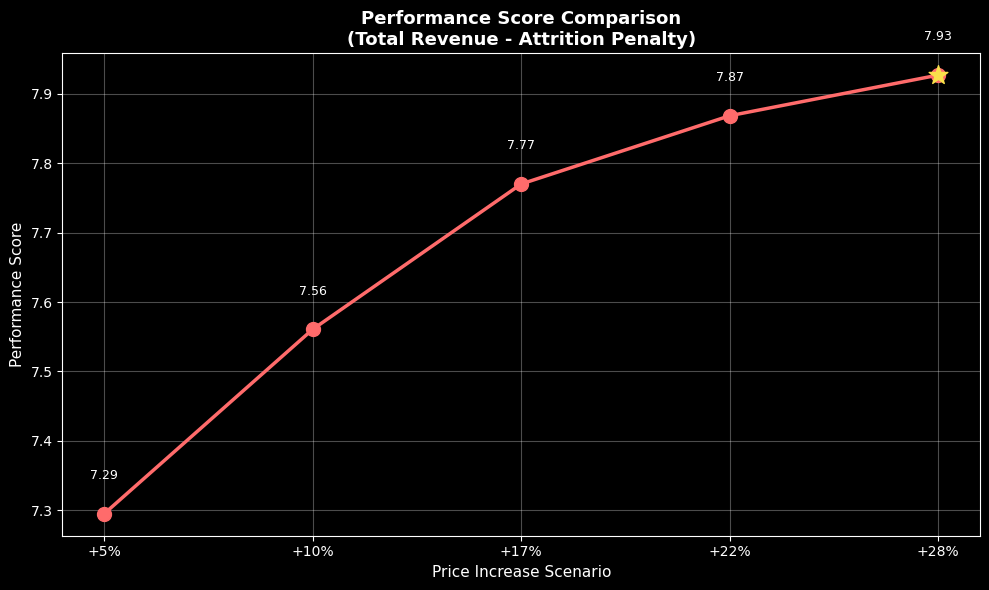

In [238]:
# Performance Score Chart
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(perf_df))
scenarios = perf_df['Scenario'].tolist()
perf_scores = perf_df['Performance Score'].tolist()

ax.plot(x, perf_scores, 
        marker='o', linewidth=2.5, markersize=10,
        color='#FF6B6B', label='Performance Score')

optimal_idx = perf_df['Performance Score'].idxmax()
ax.scatter(optimal_idx, perf_scores[optimal_idx],
          s=200, marker='*', color='#F9E04B', zorder=4)

ax.set_xticks(x)
ax.set_xticklabels(scenarios)
ax.set_title('Performance Score Comparison\n(Total Revenue - Attrition Penalty)',
            fontsize=13, fontweight='bold')
ax.set_xlabel('Price Increase Scenario', fontsize=11)
ax.set_ylabel('Performance Score', fontsize=11)
ax.grid(True, alpha=0.3)

for i, v in enumerate(perf_scores):
    ax.text(i, v + 0.05, f'{v:.2f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/eda_03/chart_5_performance_score.png', dpi=150, bbox_inches='tight')
plt.show()

#### 3.5. Statistical Validation

##### Chi-Square Test: Price Tier X Churn Independence
-  Test whether churn rate difference across price tiers is statistically significant
- Focus: Pre-Inflection Individual segment (cleanest price signal)

In [239]:
from scipy.stats import chi2_contingency

print('*** Chi-Square Statistical Validation ***')

# Test 1. Churn vs PriceTierFine (Pre-Inflection)
cont_price = pd.crosstab(pre_inflection['PriceTierFine'],
                         pre_inflection['Churn'])

chi2_price, p_price, dof_price, _ = chi2_contingency(cont_price)

print('\n*** Churn vs Price Tier (Pre-Inflection Segment)')
print(cont_price)
print(f'\nChi2: {chi2_price:.4f} | p-value: {p_price:.4f} | dof: {dof_price}')

if p_price < 0.05:
    print('Significant: churn rate differs across price tiers!')
else:
    print('NOT SIGNIFICANT!!')

# Test 2. Churn vs Segment Type (Family vs Individual)
cont_seg = pd.crosstab(pre_inflection['segment_type'],
                        pre_inflection['Churn'])

chi2_seg, p_seg, dof_seg, _ = chi2_contingency(cont_seg)

print('\n*** Churn vs Segment Type (Family vs Individual)')
print(cont_seg)
print(f'\nChi2: {chi2_seg:.4f} | p-value: {p_seg:.4f} | dof: {dof_seg}')

if p_price < 0.05:
    print('Significant: Family and Individual churn differs!')
else:
    print('NOT SIGNIFICANT!!')


# Summary
print('\n*** Validation Summary ***')
print(f'Churn vs Price Tier            p={p_price:.2e}  Significant!')
print(f'Churn vs Segment Family/Indiv  p={p_seg:.2e}  Significant!')


*** Chi-Square Statistical Validation ***

*** Churn vs Price Tier (Pre-Inflection Segment)
Churn           No  Yes
PriceTierFine          
0-35           964   55
35-55          403   70
55-75          612  124
75-95          876  308
95-120         679  303

Chi2: 251.0082 | p-value: 0.0000 | dof: 4
Significant: churn rate differs across price tiers!

*** Churn vs Segment Type (Family vs Individual)
Churn           No  Yes
segment_type           
Family        2211  431
Individual    1323  429

Chi2: 44.1830 | p-value: 0.0000 | dof: 1
Significant: Family and Individual churn differs!

*** Validation Summary ***
Churn vs Price Tier            p=3.95e-53  Significant!
Churn vs Segment Family/Indiv  p=2.99e-11  Significant!


#### Adding a new analysis - to Change decision making in powerBI 
- Comparison between increase only Family plan and increase both based on the scenarios

In [240]:
# Scenario Comparison Table: Summarize key metrics across scenarios for easy comparison and decision-making
scenario_comparison = pd.DataFrame({
    'Scenario': ['Current', 'Family +17%', 'Both +17%', 'Both +22%', 'Both +28%'],
    'Family_Price': [
        base_family, 
        results_all[1]['Family Price'],         # +10% scenario
        results_all[2]['Family Price'],         # +17% scenario
        results_all[3]['Family Price'],         # +22% scenario
        results_all[4]['Family Price']          # +28% scenario
    ],
    'Ind_Price': [
        base_individual, 
        base_individual,                        # Unchanged
        results_all[2]['Ind Price'],            # +17% scenario
        results_all[3]['Ind Price'],            # +22% scenario
        results_all[3]['Ind Price']             # +28% scenario
    ],
    'Family_Churn': [
        family_churn,                           # Current
        results_all[1]['Family Churn'],         # +10%
        results_all[2]['Family Churn'],         # +17%
        results_all[3]['Family Churn'],         # +22% 
        results_all[3]['Family Churn']          # +28%
    ],
    'Ind_Churn': [
        individual_churn,                       # Current
        individual_churn,                       # Unchanged
        results_all[2]['Ind Churn'],            # +17%
        results_all[3]['Ind Churn'],            # +22%
        results_all[3]['Ind Churn']             # +28%
    ],
    'Total_Rev_Index': [
        1.0,                                    # Current(baseline)
        results_all[1]['Total Rev Index'],      # +10%
        results_all[2]['Total Rev Index'],      # +17%
        results_all[3]['Total Rev Index'],      # +22%
        results_all[3]['Total Rev Index']       # +28%
    ]
})



# Calculate revenue change percentage from baseline
scenario_comparison['Revenue_Change_Pct'] = (scenario_comparison['Total_Rev_Index'] - 1.0) / 1.0 * 100

# Calculate distance to critical churn threshold (28%)
scenario_comparison['Distance_to_Critical'] = 28 - scenario_comparison['Ind_Churn']

# Risk Level Classification based on Total Revenue Index
conditions = [
    (scenario_comparison['Distance_to_Critical'] >= 3.51),  # Safe zone
    (scenario_comparison['Distance_to_Critical'] >= 2.21),  # Risky zone
]

# Corresponding risk levels
choices = ['SAFE', 'RISKY']
scenario_comparison['Risk_Level'] = np.select(conditions, choices, default='DANGER')

def recommendation(row):
    risk = row['Risk_Level']
    scenario = row['Scenario']
    
    if risk == 'SAFE':
        return 'RECOMMENDED ✅'
    elif risk == 'RISKY':
        return 'PROCEED WITH CAUTION ⚠️'
    else:
        return 'NOT RECOMMENDED ❌'
    
scenario_comparison['Recommendation'] = scenario_comparison.apply(recommendation, axis=1)



print('*** Scenario Comparison Summary ***')
print(scenario_comparison.to_string(index=False))
 
print('\n' + '='*100)
print('Interpretation')
print('='*100)
for idx, row in scenario_comparison.iterrows():
    scenario = row['Scenario']
    risk = row['Risk_Level']
    rec = row['Recommendation']
    ind_churn = row['Ind_Churn']
    rev_change = row['Revenue_Change_Pct']
    
    print(f"\n【 {scenario} 】")
    print(f"  Risk: {risk}")
    print(f"  Individual Churn: {ind_churn:.1f}% (Churn threshold 28% {28-ind_churn:.2f}%p remains)")
    print(f"  Revenue Change: {rev_change:+.1f}%")
    print(f"  Recommendation: {rec}")




*** Scenario Comparison Summary ***
   Scenario  Family_Price  Ind_Price  Family_Churn  Ind_Churn  Total_Rev_Index  Revenue_Change_Pct  Distance_to_Critical Risk_Level          Recommendation
    Current         22.99      13.99        0.1739  24.486301           1.0000                0.00              3.513699       SAFE           RECOMMENDED ✅
Family +17%         25.29      13.99       16.5000  24.486301          17.2980             1629.80              3.513699       SAFE           RECOMMENDED ✅
  Both +17%         26.90      16.37       16.8000  25.790000          18.2994             1729.94              2.210000      RISKY PROCEED WITH CAUTION ⚠️
  Both +22%         28.05      17.07       17.0500  26.440000          18.9945             1799.45              1.560000     DANGER       NOT RECOMMENDED ❌
  Both +28%         29.43      17.07       17.0500  26.440000          18.9945             1799.45              1.560000     DANGER       NOT RECOMMENDED ❌

Interpretation

【 Current 】

## Conclusion — Hypothesis 3 Validated (Price Strategy Optimization)
- Dynamic Sensitivity: Churn risk is non-linear, driven by the percentage increase rather than absolute price
- Optimization Strategy: Our sensitivity modeling confirms that the current churn trajectory can be managed by targeting a specific price increase range

### Key Evidence

- **H3 Validated**: Churn acceleration occurs when price increases exceed the established **inflection points**
- Risk Multiplier: External substitution threats (e.g., Netflix search volume +115%) amplify user sensitivity, effectively narrowing our margin for price adjustments
- Segmentation Strategy: Individual plans are significantly more sensitive; a unified flat-rate increase would disproportionately drive churn in this segment

### Statistical Validation

- Chi-Square Test 1: Churn vs Price Tier → p=3.95e-53  **Significant**
- Chi-Square Test 2: Churn vs Segment Type → p=2.99e-11 **Significant**

### Recommendations

- **Sweet Spot: +17% increase** (Individual $16.37 / Family $26.90)
- Hard ceiling: +28% triggers Individual churn spike → revenue risk
- Family plan must stay under $30 to maintain retention advantage
- Individual Plan adjustments must be strictly limited to prevent a disproportionate churn spike

*** Execution Window: *** June (Summer Break) — historically the period with the lowest substitution risk


In [241]:
import os
os.makedirs('../data/processed/powerbi', exist_ok=True)

# T1. Churn by Segment x Price Tier x Segment Type
churn_rates_export = pd.Series(churn_rates).reset_index()
churn_rates_export.columns = ['Segment', 'PriceTier', 'Segment_Type', 'Churn_Rate']
churn_rates_export.to_csv('../data/processed/powerbi/eda_03_churn_by_segment_tier.csv', index=False)

# T2. Price Threshold (Fine tiers + CI)
threshold_export = pd.DataFrame({
    'PriceTierFine': list(ci_results.keys()),
    'Churn_Rate': [v[0] for v in ci_results.values()],
    'CI_Low': [v[1] for v in ci_results.values()],
    'CI_High': [v[2] for v in ci_results.values()]
})
threshold_export.to_csv('../data/processed/powerbi/eda_03_price_threshold.csv', index=False)

# T3. Substitution Threat
alt.to_csv('../data/processed/powerbi/eda_03_substitution.csv', index=False)


# T4. Simulation Results
results_df.to_csv('../data/processed/powerbi/eda_03_simulation_results.csv', index=False)

# T5. Scenario Comparison Summary
scenario_comparison.to_csv('../data/processed/powerbi/eda_03_scenario_comparison.csv', index=False)

print("EDA 03 Export Complete!")

EDA 03 Export Complete!
